# 05 — Modelo FastText

Clasificación de CVs en 24 categorías usando FastText de Facebook.

**Estrategia:** FastText nativo (`fasttext` library) con su propio pipeline interno de subword embeddings. Es el enfoque más directo y rápido — entrena embeddings y clasificador en un solo paso.

**Input:** texto limpio en formato `.txt` con etiquetas `__label__<CLASE>` (formato nativo de FastText).

**Métricas:** Accuracy, Precision weighted, Recall weighted, F1 weighted, ROC-AUC OvR weighted.

## 0. Imports y configuración

In [1]:
import os
import re
import math
import time
import json
import pickle
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import fasttext

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

import fasttext.util
print(fasttext.util.__doc__)

None


In [2]:
# --- Rutas ---
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_PATH     = os.path.join(BASE_DIR, 'data', 'Resume.csv')
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
METRICS_DIR   = os.path.join(ARTIFACTS_DIR, 'metrics')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
TEMP_DIR      = os.path.join(BASE_DIR, 'artifacts', 'fasttext_tmp')  # archivos .txt temporales

for d in [METRICS_DIR, MODELS_DIR, TEMP_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Rutas OK')
print(f'BASE_DIR: {BASE_DIR}')

Rutas OK
BASE_DIR: /home/alejo/DeepLearning/miniproyecto3


## 1. Carga de datos y artefactos

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset: {df.shape}')
print(df.head(2))

Dataset: (2484, 4)
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  


In [4]:
# Cargar LabelEncoder y config desde artefactos
with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)

NUM_CLASSES = config['NUM_CLASSES']
CLASS_NAMES = list(le.classes_)

print(f'NUM_CLASSES: {NUM_CLASSES}')
print(f'CLASS_NAMES: {CLASS_NAMES}')

NUM_CLASSES: 24
CLASS_NAMES: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


## 2. Preprocesamiento y split

Mismo pipeline de limpieza que el resto del proyecto. El split se reproduce con `random_state=42` para garantizar consistencia con los artefactos guardados.

In [5]:
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) >= 3]
    return ' '.join(tokens)

if 'clean_text' not in df.columns:
    df['clean_text'] = df['Resume_str'].apply(clean_text)
    print('clean_text generado')
else:
    print('clean_text ya existe en el dataframe')

clean_text generado


In [6]:
# Reproducir split con la misma semilla que los otros notebooks
y_encoded = le.transform(df['Category'])
idx_all   = np.arange(len(df))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all, y_encoded, test_size=0.30, stratify=y_encoded, random_state=RANDOM_STATE
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

text_train = df['clean_text'].iloc[idx_train].values
text_val   = df['clean_text'].iloc[idx_val].values
text_test  = df['clean_text'].iloc[idx_test].values

# Verificar consistencia
y_train_saved = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_val_saved   = np.load(os.path.join(ARTIFACTS_DIR, 'y_val.npy'))
y_test_saved  = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))

assert np.array_equal(y_train, y_train_saved), 'ERROR: y_train no coincide con artefacto'
assert np.array_equal(y_val,   y_val_saved),   'ERROR: y_val no coincide con artefacto'
assert np.array_equal(y_test,  y_test_saved),  'ERROR: y_test no coincide con artefacto'

print(f'Split OK — train: {len(text_train)}, val: {len(text_val)}, test: {len(text_test)}')

Split OK — train: 1738, val: 373, test: 373


## 3. Preparar archivos en formato FastText

FastText nativo requiere archivos `.txt` donde cada línea tiene el formato:
```
__label__CATEGORIA texto del documento
```

In [7]:
def write_fasttext_file(texts, labels, filepath):
    """Escribe archivo en formato FastText: __label__CLASE texto"""
    with open(filepath, 'w', encoding='utf-8') as f:
        for text, label in zip(texts, labels):
            class_name = CLASS_NAMES[label]
            # Reemplazar guiones por underscore (FastText trata espacios como separadores)
            class_name = class_name.replace('-', '_')
            f.write(f'__label__{class_name} {text}\n')

TRAIN_FILE = os.path.join(TEMP_DIR, 'train.txt')
VAL_FILE   = os.path.join(TEMP_DIR, 'val.txt')
TEST_FILE  = os.path.join(TEMP_DIR, 'test.txt')

write_fasttext_file(text_train, y_train, TRAIN_FILE)
write_fasttext_file(text_val,   y_val,   VAL_FILE)
write_fasttext_file(text_test,  y_test,  TEST_FILE)

print(f'Archivos FastText escritos en {TEMP_DIR}')

# Verificar primeras líneas
with open(TRAIN_FILE) as f:
    for i, line in enumerate(f):
        print(f'[{i}] {line[:100]}')
        if i >= 2: break

Archivos FastText escritos en /home/alejo/DeepLearning/miniproyecto3/artifacts/fasttext_tmp
[0] __label__SALES sales summary focused dedicated insurance professional motivated provide superior cus
[1] __label__CHEF owner executive chef career focus performance driven administrative professional exten
[2] __label__CONSTRUCTION construction services project manager summary dedicated property facilities sp


## 4. Entrenamiento

FastText tiene dos funciones principales:
- `fasttext.train_supervised` — clasificación (nuestro caso)
- `fasttext.train_unsupervised` — solo embeddings

**Hiperparámetros clave:**
- `epoch`: número de pasadas sobre los datos
- `lr`: learning rate
- `wordNgrams`: n-gramas de palabras (1=unigramas, 2=bigramas)
- `dim`: dimensión de los embeddings de subwords
- `minCount`: frecuencia mínima de una palabra para incluirla
- `loss`: función de pérdida — `softmax` para multiclase, `ova` (one-vs-all) como alternativa

In [8]:
# Configuración — valores razonables para este dataset
FT_PARAMS = dict(
    input      = TRAIN_FILE,
    epoch      = 50,
    lr         = 0.3,
    wordNgrams = 1,       # bigramas capturan colocaciones tipo "project management"
    dim        = 100,
    minCount   = 1,
    loss       = 'softmax',
    thread     = 4,
    seed       = RANDOM_STATE,
    verbose    = 2,
)

print('Parámetros de entrenamiento:')
for k, v in FT_PARAMS.items():
    if k != 'input':
        print(f'  {k}: {v}')

Parámetros de entrenamiento:
  epoch: 50
  lr: 0.3
  wordNgrams: 1
  dim: 100
  minCount: 1
  loss: softmax
  thread: 4
  seed: 42
  verbose: 2


In [9]:
print('Entrenando FastText...')
t0 = time.time()

model_ft = fasttext.train_supervised(**FT_PARAMS)

train_time = time.time() - t0
print(f'\nEntrenamiento completado en {train_time:.1f}s')

Entrenando FastText...


Read 1M words
Number of words:  31295
Number of labels: 24
Progress: 100.0% words/sec/thread: 6693879 lr:  0.000000 avg.loss:  1.207413 ETA:   0h 0m 0s



Entrenamiento completado en 2.1s


In [10]:
# Evaluación rápida en val (métrica nativa de FastText)
n_val, p_val, r_val = model_ft.test(VAL_FILE)
print(f'Validation — N: {n_val}, Precision@1: {p_val:.4f}, Recall@1: {r_val:.4f}')

# Guardar modelo
MODEL_PATH = os.path.join(MODELS_DIR, 'fasttext_model.bin')
model_ft.save_model(MODEL_PATH)
print(f'Modelo guardado en {MODEL_PATH}')

Validation — N: 373, Precision@1: 0.6032, Recall@1: 0.6032
Modelo guardado en /home/alejo/DeepLearning/miniproyecto3/models/fasttext_model.bin


## 5. Predicción y métricas en test

In [11]:
def predict_fasttext(model, texts):
    # Usar el orden real del modelo
    ft_label_to_idx = {
        label: i 
        for i, label in enumerate(model.labels)
    }
    # Mapa de índice FastText → índice CLASS_NAMES
    ft_idx_to_class_idx = {
        ft_idx: CLASS_NAMES.index(label.replace('__label__', '').replace('_', '-'))
        for label, ft_idx in ft_label_to_idx.items()
    }
    
    labels_list, probs_list = model.predict(list(texts), k=NUM_CLASSES)
    
    n = len(texts)
    y_proba = np.zeros((n, NUM_CLASSES), dtype=np.float32)
    y_pred  = np.zeros(n, dtype=int)
    
    for i, (labels, probs) in enumerate(zip(labels_list, probs_list)):
        for label, prob in zip(labels, probs):
            ft_idx = ft_label_to_idx[label]
            class_idx = ft_idx_to_class_idx[ft_idx]
            y_proba[i, class_idx] = prob
        y_pred[i] = np.argmax(y_proba[i])
    
    return y_pred, y_proba

In [13]:
print('Prediciendo en test...')
y_pred_test, y_proba_test = predict_fasttext(model_ft, text_test)
print(f'y_pred_test shape: {y_pred_test.shape}')
print(f'y_proba_test shape: {y_proba_test.shape}')

Prediciendo en test...
y_pred_test shape: (373,)
y_proba_test shape: (373, 24)


In [14]:
# Calcular métricas
acc       = accuracy_score(y_test, y_pred_test)
prec      = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec       = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
y_proba_test = y_proba_test / y_proba_test.sum(axis=1, keepdims=True)
roc_auc   = roc_auc_score(y_test, y_proba_test, multi_class='ovr', average='weighted')

# Binarizar para curvas por clase
y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))

# MAP
map_score = average_precision_score(y_test_bin, y_proba_test, average='weighted')

print(f'Accuracy:          {acc:.4f}')
print(f'Precision (w):     {prec:.4f}')
print(f'Recall (w):        {rec:.4f}')
print(f'F1 (w):            {f1:.4f}')
print(f'ROC-AUC (OvR w):   {roc_auc:.4f}')
print(f'MAP (w):           {map_score:.4f}')

Accuracy:          0.6461
Precision (w):     0.6399
Recall (w):        0.6461
F1 (w):            0.6346
ROC-AUC (OvR w):   0.9473
MAP (w):           0.7037


In [15]:
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.67      0.94      0.78        17
              ADVOCATE       0.50      0.71      0.59        17
           AGRICULTURE       0.33      0.20      0.25        10
               APPAREL       0.46      0.43      0.44        14
                  ARTS       0.37      0.44      0.40        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.79      0.83      0.81        18
               BANKING       0.65      0.72      0.68        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.65      0.83      0.73        18
                  CHEF       0.82      0.82      0.82        17
          CONSTRUCTION       0.93      0.76      0.84        17
            CONSULTANT       0.38      0.33      0.35        18
              DESIGNER       0.69      0.69      0.69        16
         DIGITAL-MEDIA       0.58      

## 6. Visualizaciones

### 6.1 Matriz de confusión

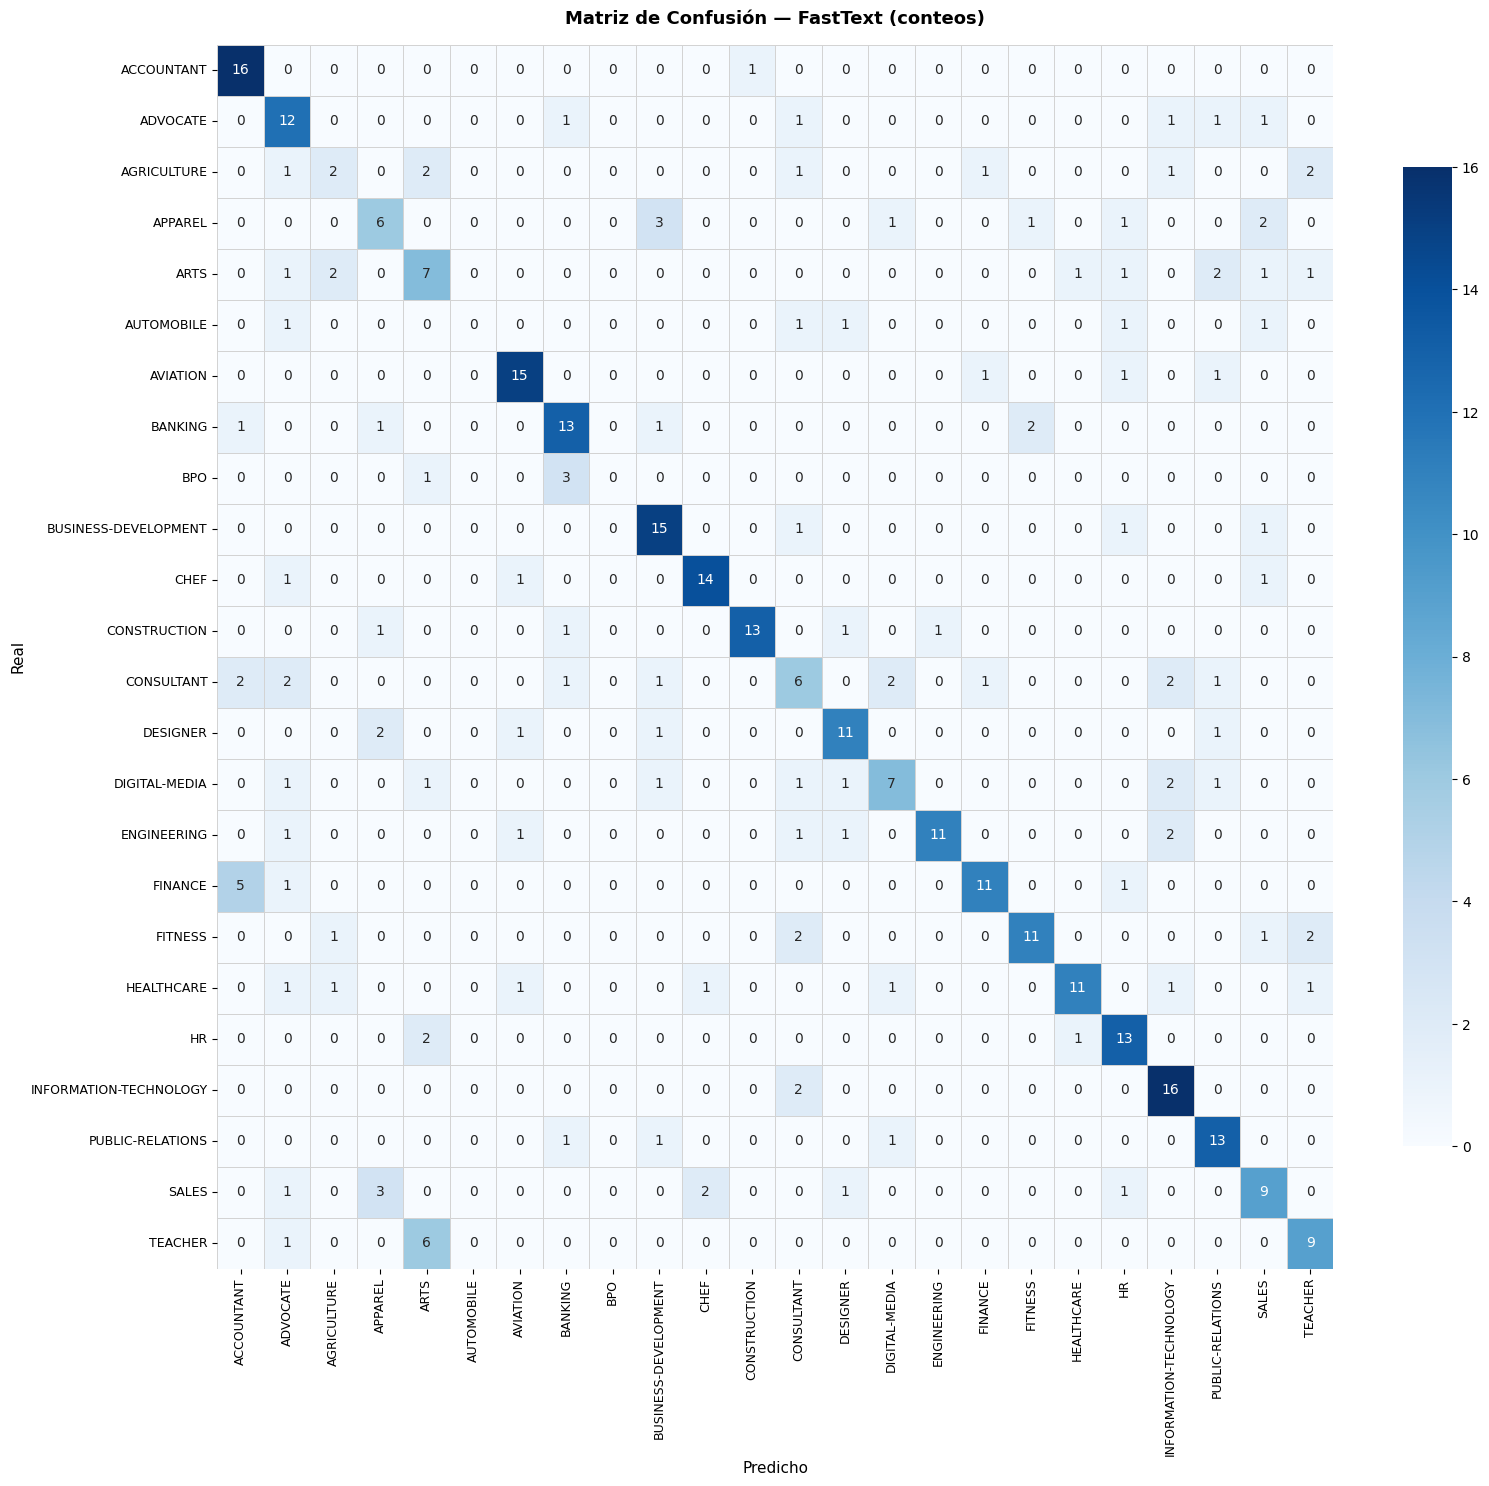

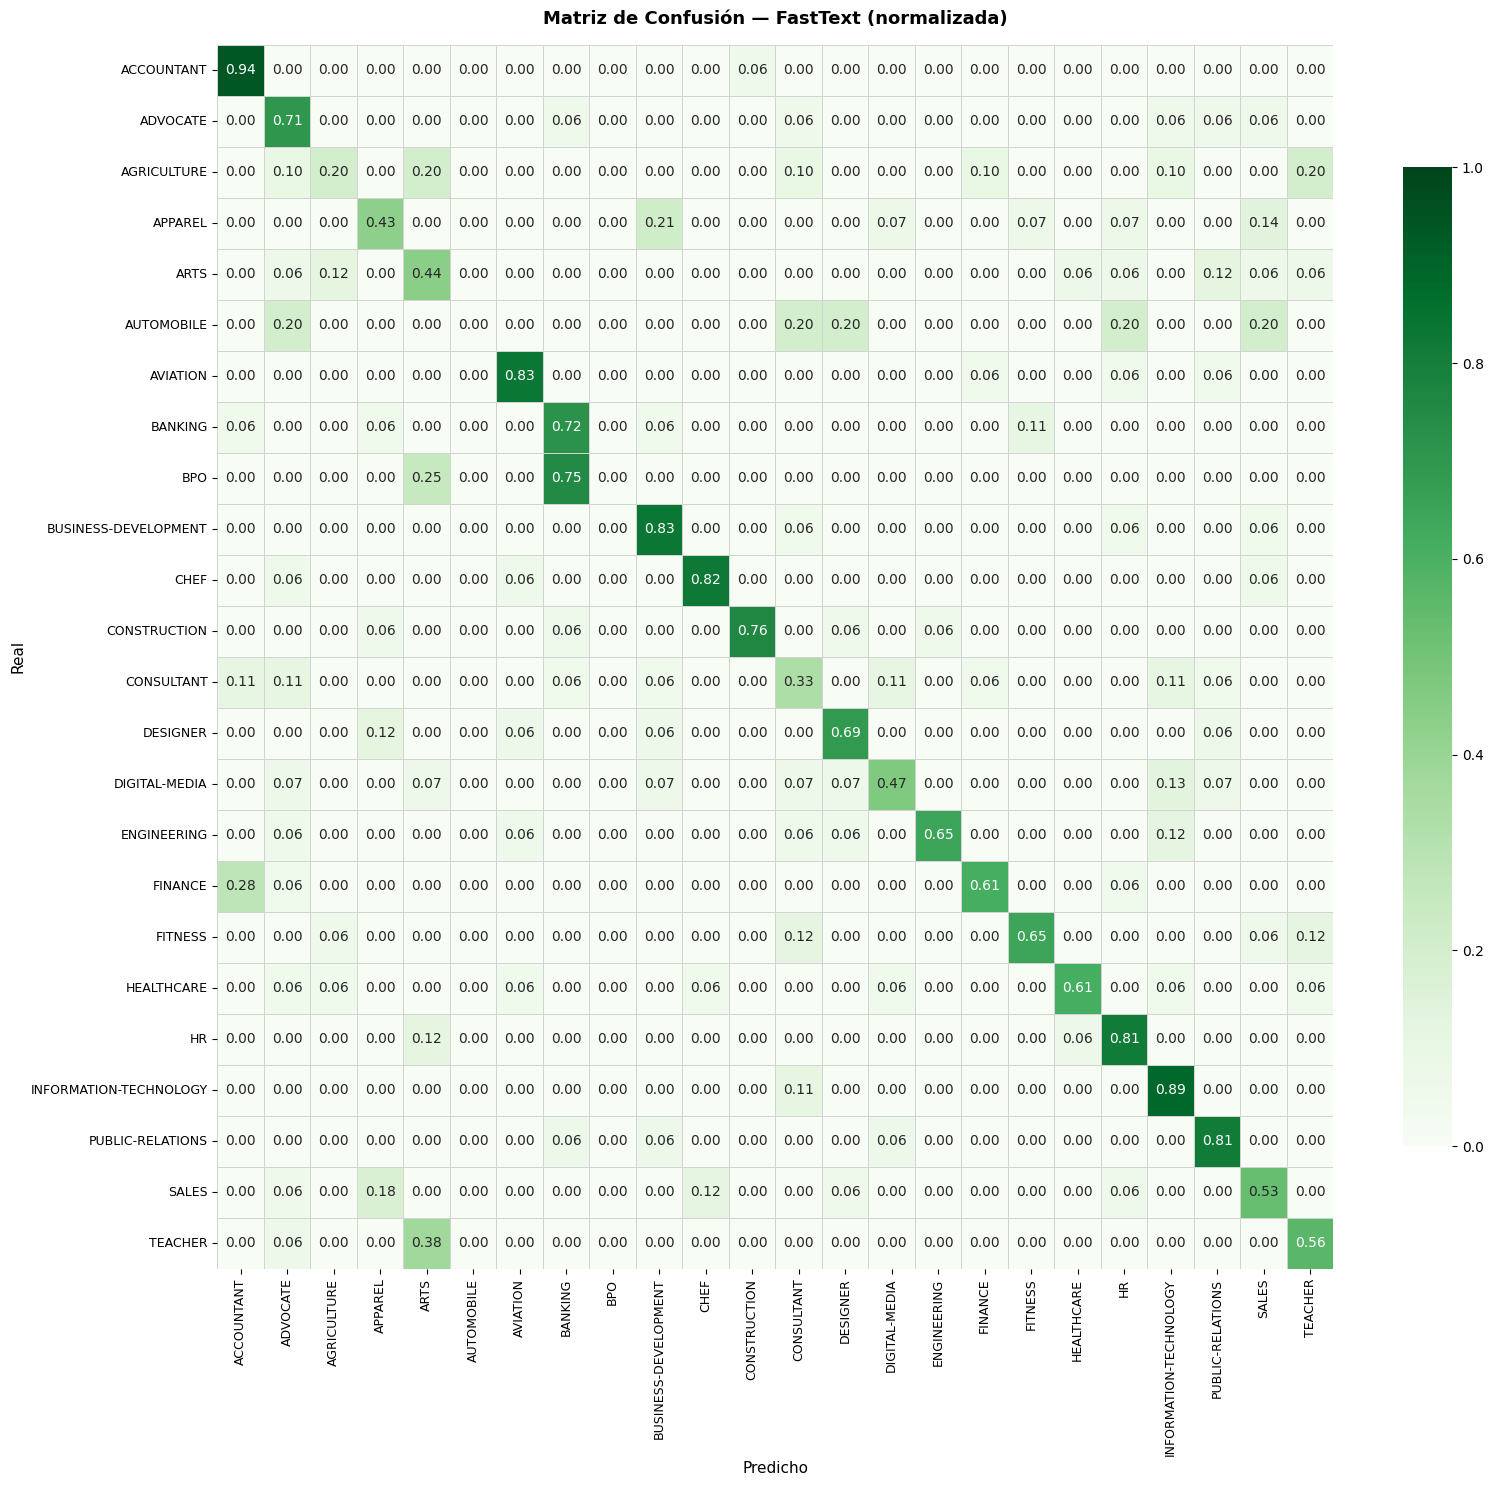

In [16]:
cm      = confusion_matrix(y_test, y_pred_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

cell_size = 0.75
fig_side  = max(12, NUM_CLASSES * cell_size)

# Figura 1: conteos absolutos
fig1, ax1 = plt.subplots(figsize=(fig_side, fig_side))
sns.heatmap(cm, ax=ax1, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='lightgray', cbar_kws={'shrink': 0.8})
ax1.set_title('Matriz de Confusión — FastText (conteos)', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Predicho', fontsize=11)
ax1.set_ylabel('Real', fontsize=11)
ax1.tick_params(axis='x', rotation=90, labelsize=9)
ax1.tick_params(axis='y', rotation=0,  labelsize=9)
plt.subplots_adjust(bottom=0.2)
plt.show()

# Figura 2: normalizada
fig2, ax2 = plt.subplots(figsize=(fig_side, fig_side))
sns.heatmap(cm_norm, ax=ax2, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='lightgray', vmin=0, vmax=1,
            cbar_kws={'shrink': 0.8})
ax2.set_title('Matriz de Confusión — FastText (normalizada)', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Predicho', fontsize=11)
ax2.set_ylabel('Real', fontsize=11)
ax2.tick_params(axis='x', rotation=90, labelsize=9)
ax2.tick_params(axis='y', rotation=0,  labelsize=9)
plt.subplots_adjust(bottom=0.2)
plt.show()

### 6.2 Curvas ROC por clase

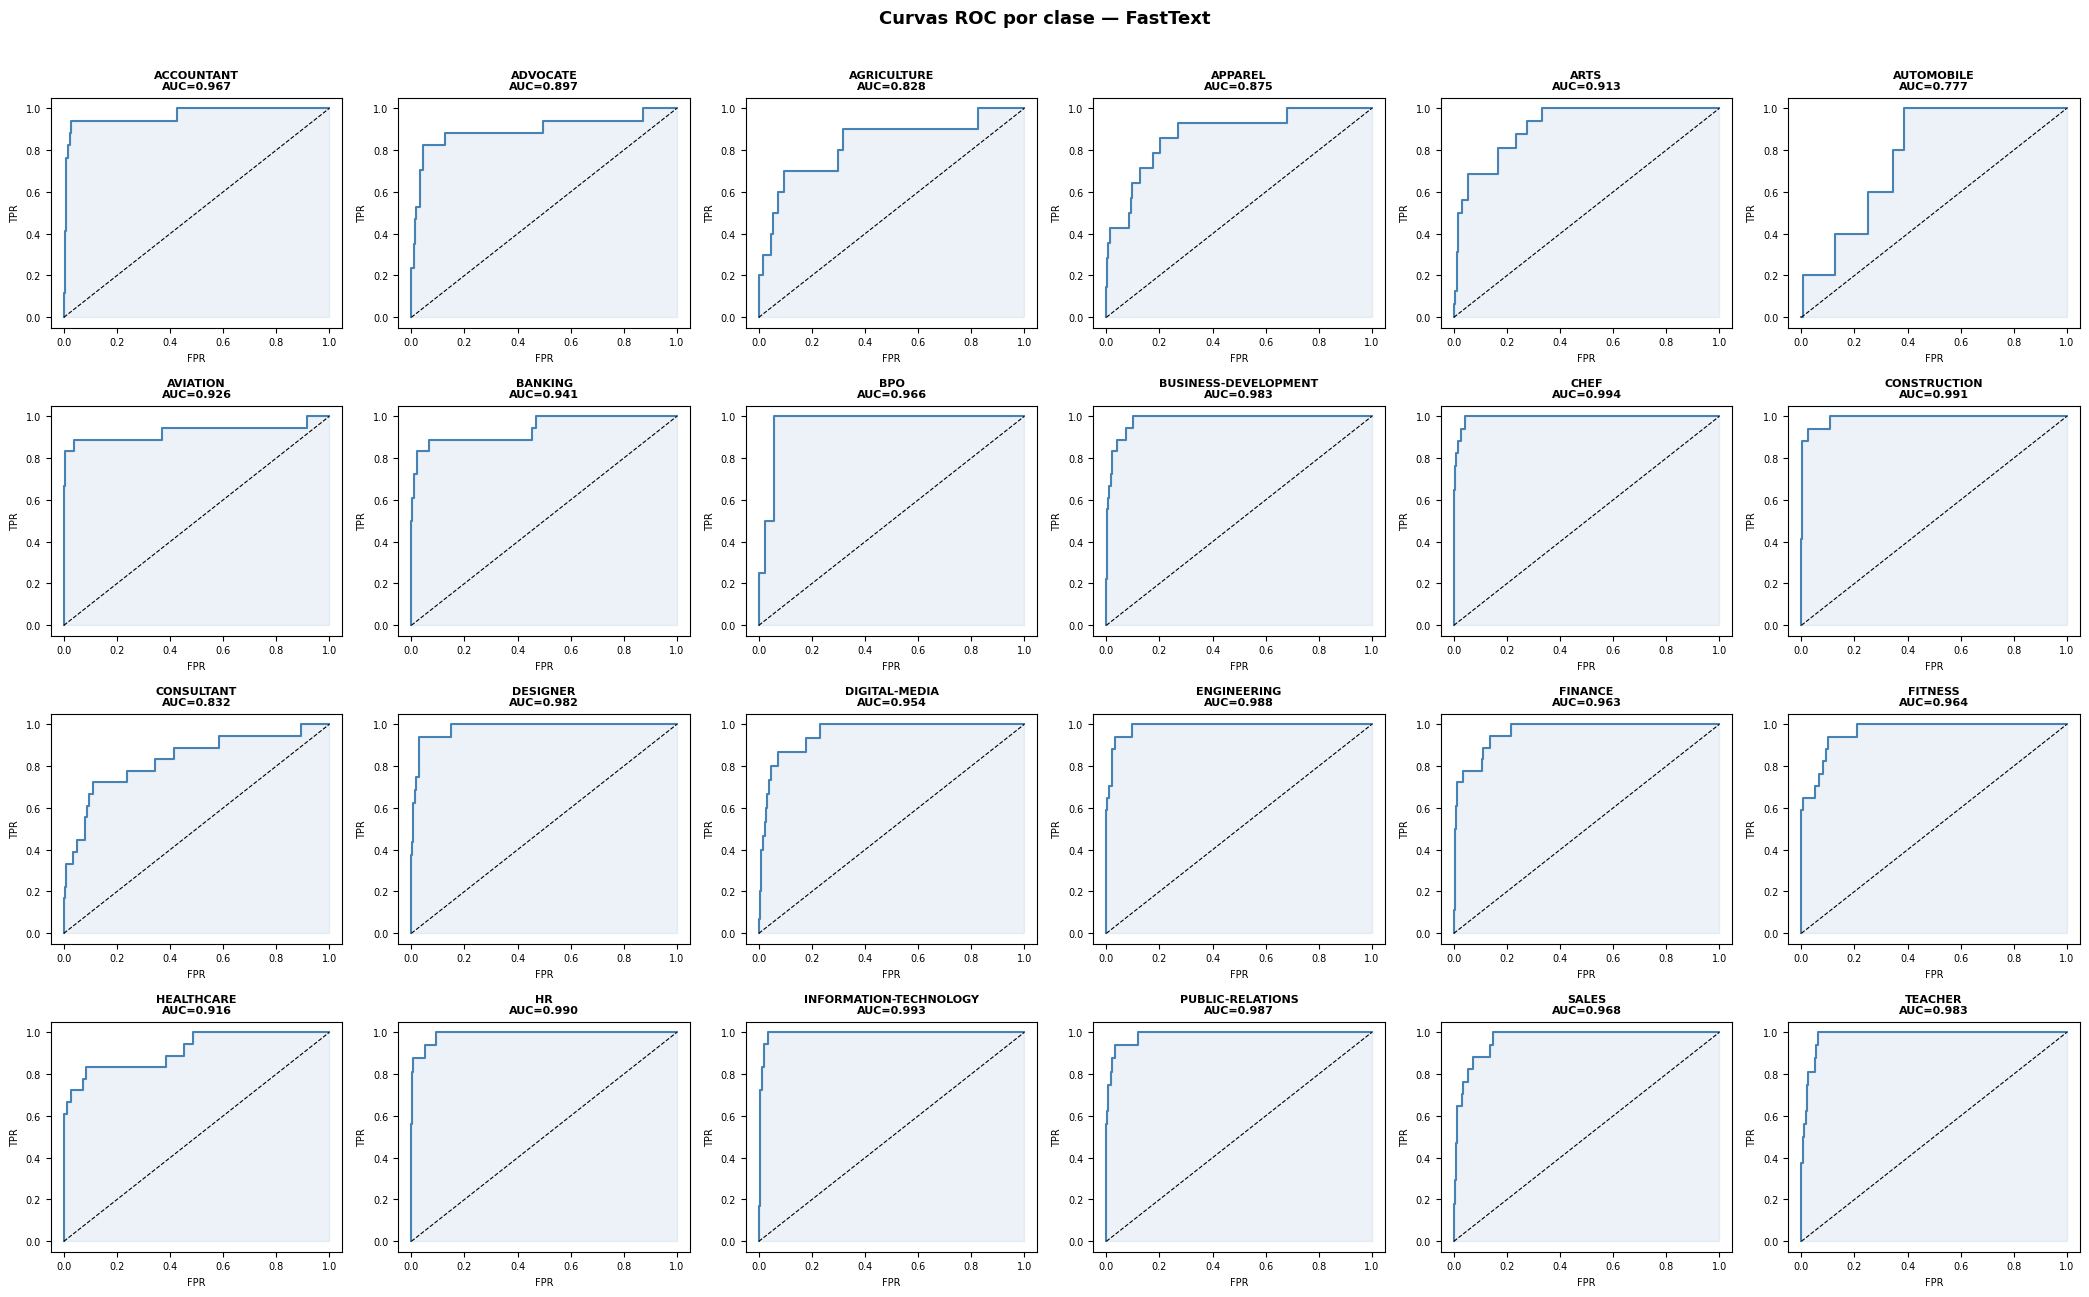

In [26]:
fpr_dict     = {}
tpr_dict     = {}
roc_auc_dict = {}

for i in range(NUM_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    roc_auc_dict[i] = roc_auc_score(y_test_bin[:, i], y_proba_test[:, i])

n_cols = 6
n_rows = math.ceil(NUM_CLASSES / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
fig.suptitle('Curvas ROC por clase — FastText', fontsize=13, fontweight='bold', y=1.01)

for i in range(NUM_CLASSES):
    ax = axes.flatten()[i]
    ax.plot(fpr_dict[i], tpr_dict[i], color='steelblue', lw=1.5)
    ax.fill_between(fpr_dict[i], tpr_dict[i], alpha=0.1, color='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{CLASS_NAMES[i]}\nAUC={roc_auc_dict[i]:.3f}", fontsize=8, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=7)
    ax.set_ylabel('TPR', fontsize=7)
    ax.tick_params(labelsize=7)

# Ocultar subplots sobrantes
for j in range(NUM_CLASSES, n_rows * n_cols):
    axes.flatten()[j].set_visible(False)

plt.tight_layout()
plt.show()

### 6.3 Curvas Precision-Recall por clase

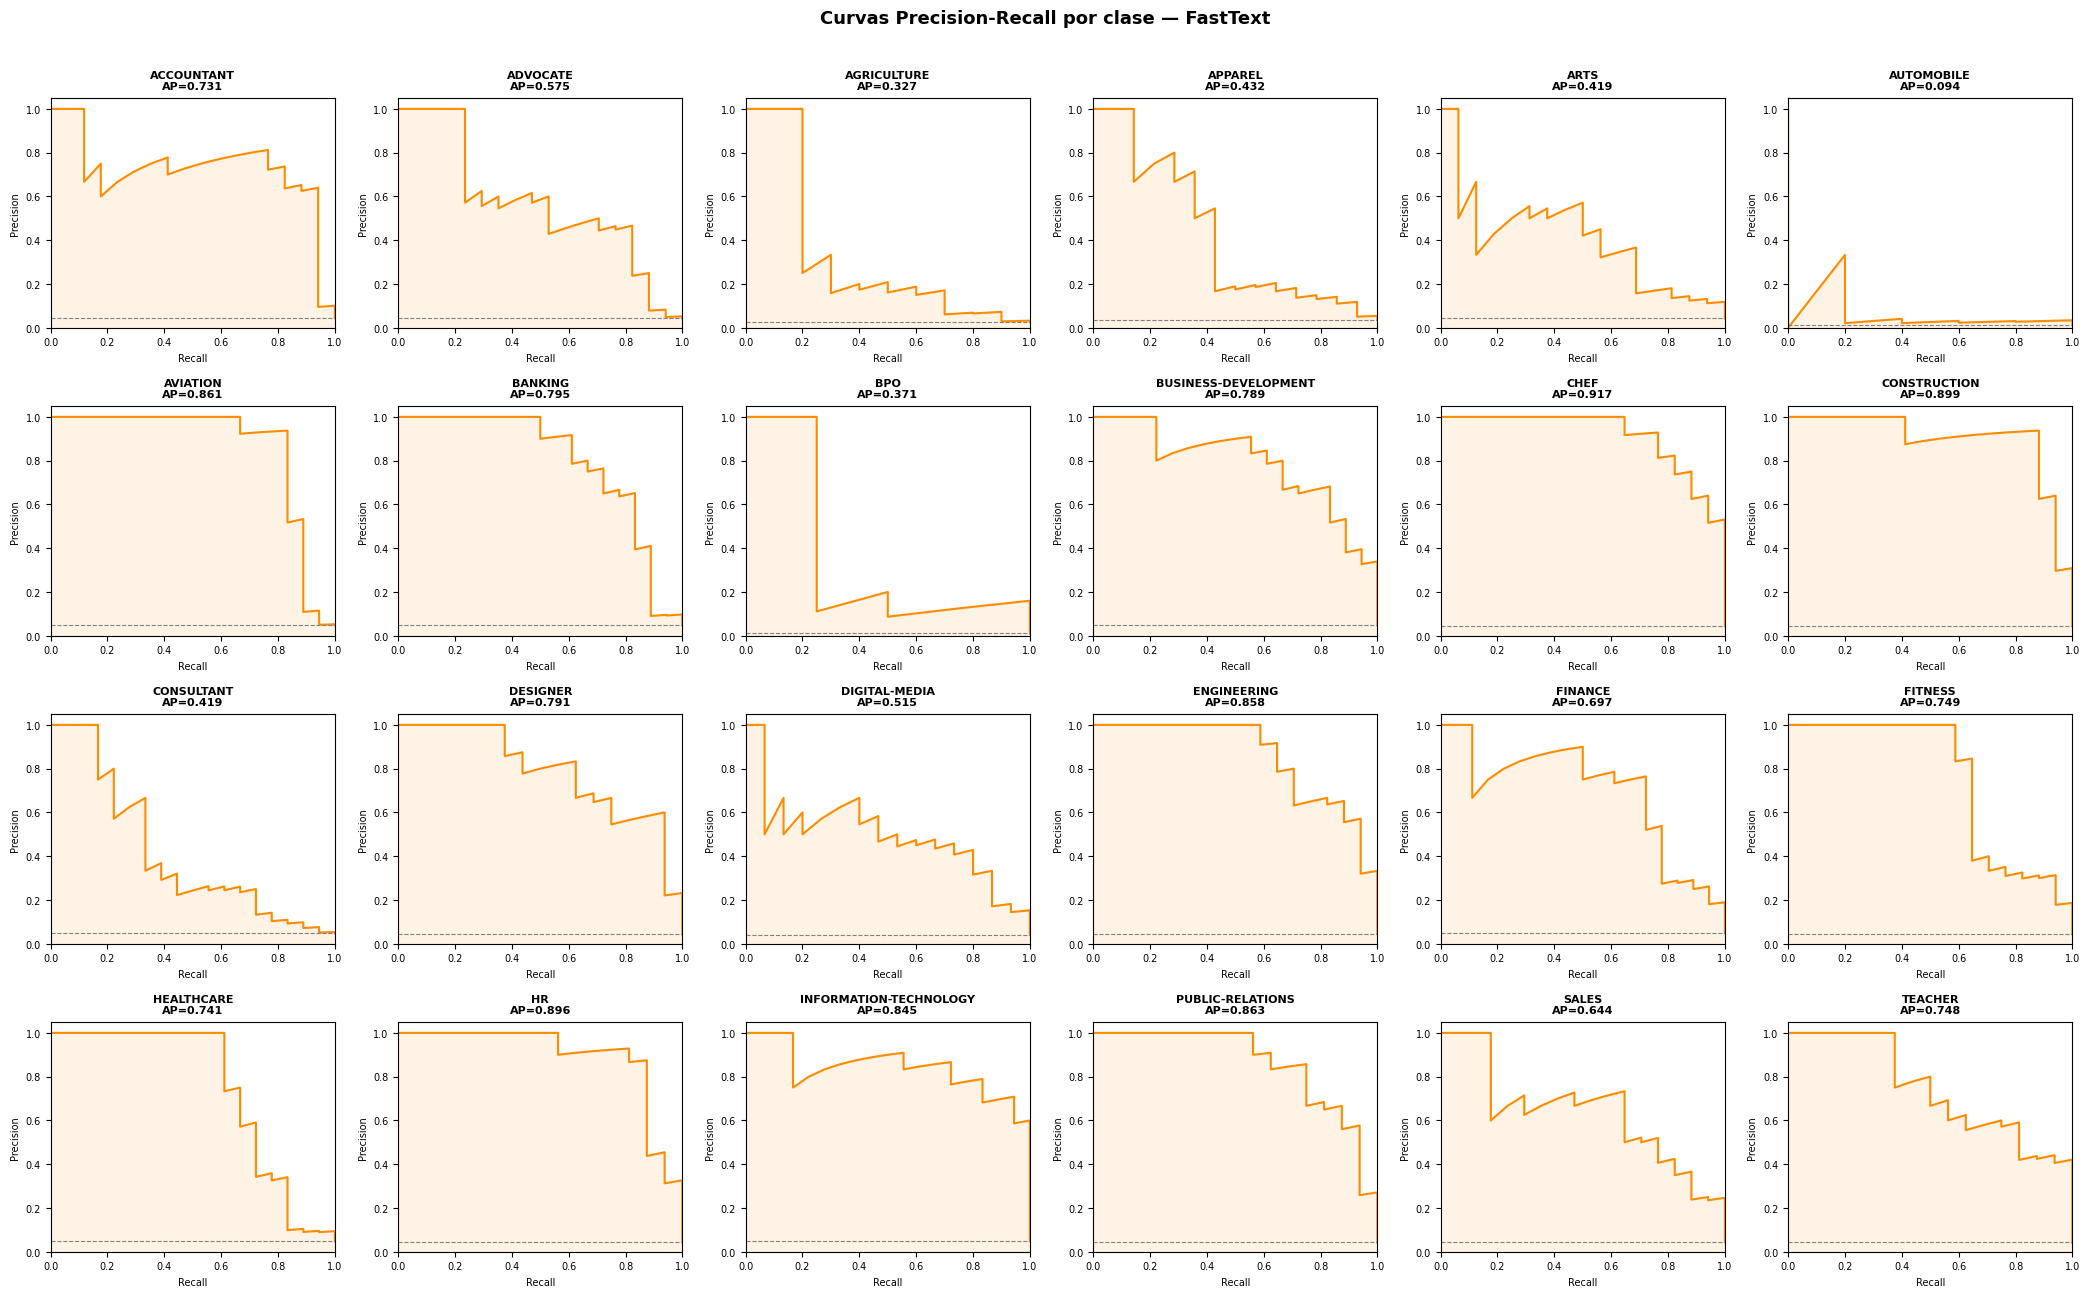

In [27]:
prec_dict    = {}
rec_dict     = {}
pr_auc_dict  = {}
class_prev   = y_test_bin.mean(axis=0)  # prevalencia por clase

for i in range(NUM_CLASSES):
    prec_dict[i], rec_dict[i], _ = precision_recall_curve(y_test_bin[:, i], y_proba_test[:, i])
    pr_auc_dict[i] = average_precision_score(y_test_bin[:, i], y_proba_test[:, i])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
fig.suptitle('Curvas Precision-Recall por clase — FastText', fontsize=13, fontweight='bold', y=1.01)

for i in range(NUM_CLASSES):
    ax = axes.flatten()[i]
    ax.plot(rec_dict[i], prec_dict[i], color='darkorange', lw=1.5)
    ax.fill_between(rec_dict[i], prec_dict[i], alpha=0.1, color='darkorange')
    ax.axhline(class_prev[i], color='gray', linestyle='--', lw=0.8, label='Baseline')
    ax.set_title(f"{CLASS_NAMES[i]}\nAP={pr_auc_dict[i]:.3f}", fontsize=8, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=7)
    ax.set_ylabel('Precision', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

for j in range(NUM_CLASSES, n_rows * n_cols):
    axes.flatten()[j].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Guardar métricas

In [28]:
# Métricas por clase
per_class = {}
report    = classification_report(y_test, y_pred_test, target_names=CLASS_NAMES,
                                   output_dict=True, zero_division=0)

for i, cn in enumerate(CLASS_NAMES):
    per_class[cn] = {
        'precision': round(float(report[cn]['precision']), 4),
        'recall':    round(float(report[cn]['recall']),    4),
        'f1':        round(float(report[cn]['f1-score']),  4),
        'support':   int(report[cn]['support']),
        'roc_auc':   round(float(roc_auc_dict[i]),         4),
        'pr_auc':    round(float(pr_auc_dict[i]),          4),
    }

metrics_dict = {
    'model':     'FastText',
    'timestamp': datetime.datetime.now().isoformat(),
    'hyperparameters': {
        'epoch':       FT_PARAMS['epoch'],
        'lr':          FT_PARAMS['lr'],
        'wordNgrams':  FT_PARAMS['wordNgrams'],
        'dim':         FT_PARAMS['dim'],
        'minCount':    FT_PARAMS['minCount'],
        'loss':        FT_PARAMS['loss'],
    },
    'metrics': {
        'accuracy':            round(float(acc),      4),
        'precision_weighted':  round(float(prec),     4),
        'recall_weighted':     round(float(rec),      4),
        'f1_weighted':         round(float(f1),       4),
        'roc_auc_ovr_weighted':round(float(roc_auc),  4),
        'mean_average_precision': round(float(map_score), 4),
    },
    'per_class':            per_class,
    'training_time_seconds': round(train_time, 1),
    'data_sizes': {'train': len(text_train), 'val': len(text_val), 'test': len(text_test)},
}

metrics_path = os.path.join(METRICS_DIR, 'fasttext_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2)

print(f'Métricas guardadas en: {metrics_path}')
print(json.dumps(metrics_dict['metrics'], indent=2))

Métricas guardadas en: /home/alejo/DeepLearning/miniproyecto3/artifacts/metrics/fasttext_metrics.json
{
  "accuracy": 0.6461,
  "precision_weighted": 0.6399,
  "recall_weighted": 0.6461,
  "f1_weighted": 0.6346,
  "roc_auc_ovr_weighted": 0.9473,
  "mean_average_precision": 0.7037
}


## 8. Análisis crítico

### ¿Qué hace bien FastText?

FastText es un clasificador lineal sobre embeddings de subwords promediados. Su fortaleza frente a los otros modelos del proyecto es la velocidad — entrena en segundos — y su manejo de palabras fuera de vocabulario (OOV), ya que puede construir un vector para cualquier palabra descomponiéndola en n-gramas de caracteres.

Para CVs, donde abundan términos técnicos y variaciones morfológicas ("programming", "programmed", "programmer"), la representación subword es una ventaja real frente a Word2Vec puro.

### Limitaciones en este dataset

Al ser un modelo lineal sobre promedios de embeddings, FastText pierde el orden de las palabras. Frases como "no experience" y "experience" tienen representaciones similares. En CVs largos (media de 584 palabras limpias), el promedio puede diluir señales importantes de secciones específicas del documento.

### Comparación con los otros modelos

- **vs TF-IDF + XGBoost:** TF-IDF captura presencia/frecuencia de bigramas de forma explícita con 50k features; FastText usa bigramas implícitamente via embeddings. XGBoost es no-lineal sobre esos features, FastText es lineal sobre embeddings.
- **vs CNN-1D y BiLSTM:** Ambos capturan contexto local/secuencial; FastText no. A cambio, FastText es órdenes de magnitud más rápido.
- **vs DistilBERT (siguiente):** DistilBERT captura contexto bidireccional profundo. FastText no tiene contexto. La brecha esperada es significativa en accuracy, a un costo de tiempo de inferencia mucho mayor.